Tensor shape: torch.Size([3, 600, 600])


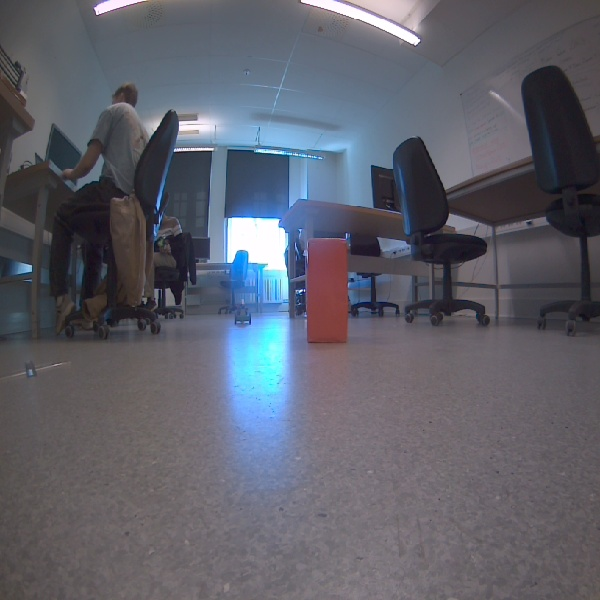

In [1]:
from torchvision import transforms
from PIL import Image

# 1. Load the image using PIL
image_path = 'redbox_distance/over60cm/20260508_085620.jpg'
image = Image.open(image_path).convert('RGB')

# 2. Define the transformation to convert the image to a Tensor
transform = transforms.ToTensor()

# 3. Apply the transformation
image_tensor = transform(image)

image_tensor = image_tensor * 255
print("Tensor shape:", image_tensor.shape)
image

In [ ]:
image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
image_np = np.ascontiguousarray(image_np.astype(np.uint8))

row, col = 77, 493
width = 45
hight = 90

cv2.rectangle(
    image_np,
    (col, row),
    (col + width, row + hight),
    (0, 0, 255),   # red in BGR (correct)
    2
)

cv2.imshow("Box", image_np)
cv2.waitKey(0)
cv2.destroyAllWindows()

image_tensor[2,110:120,520:540]

In [1]:
import requests
from urllib.parse import urlencode

# Function to execute left command
def move_left(jetbot_ip, speed):
    params = {'speed': speed}
    url = f'http://{jetbot_ip}:8080/left?{urlencode(params)}'
    response = requests.get(url)
    
    if response.status_code == 200:
        print("Left command executed successfully")
    else:
        print("Failed to execute left command")

# Function to execute right command
def move_right(jetbot_ip, speed):
    params = {'speed': speed}
    url = f'http://{jetbot_ip}:8080/right?{urlencode(params)}'
    response = requests.get(url)
    
    if response.status_code == 200:
        print("Right command executed successfully")
    else:
        print("Failed to execute right command")

# Function to execute forward command
def move_forward(jetbot_ip, speed):
    params = {'speed': speed}
    url = f'http://{jetbot_ip}:8080/forward?{urlencode(params)}'
    response = requests.get(url)
    
    if response.status_code == 200:
        print("Forward command executed successfully")
    else:
        print("Failed to execute forward command")

# Function to stop the robot
def stop(jetbot_ip):
    url = f'http://{jetbot_ip}:8080/stop'
    response = requests.get(url)
    
    if response.status_code == 200:
        print("Stop command executed successfully")
    else:
        print("Failed to execute stop command")

# Function to set motor speeds directly
def set_motors(jetbot_ip, left_speed, right_speed):
    params = {'left': left_speed, 'right': right_speed}
    url = f'http://{jetbot_ip}:8080/set_motors?{urlencode(params)}'
    response = requests.get(url)
    
    if response.status_code == 200:
        print("Motors set successfully")
    else:
        print("Failed to set motors")

# Function to retrieve current motor speeds
def get_motors(jetbot_ip):
    url = f'http://{jetbot_ip}:8080/motors'
    response = requests.get(url)
    
    if response.status_code == 200:
        try:
            data = response.json()
            print(f"Current Speeds - Left: {data['left']}, Right: {data['right']}")
            return data
        except ValueError:
            print("Failed to parse JSON response")
    else:
        print("Failed to get motor speeds")
        return None
    
    
def display_jetbot_video(jetbot_ip="localhost"):
    """
    Fetches and displays the video stream from the JetBot's HTTP server.
    :param jetbot_ip: The IP address of the JetBot (e.g., "192.168.1.50" or "localhost").
    """
    url = f"http://{jetbot_ip}:8080/camera"
    
    print(f"Connecting to video stream at {url}...")
    print("Press 'q' in the video window to close the stream.")
    
    while True:
        try:
            # Open the URL and read the JPEG image bytes
            with urllib.request.urlopen(url) as response:
                img_data = response.read()
                
            # Convert raw bytes to a NumPy array for OpenCV
            nparr = np.frombuffer(img_data, np.uint8)
            frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
            
            # Display the frame if it was successfully decoded
            if frame is not None:
                cv2.imshow('JetBot Video Stream', frame)
                
            # Exit loop when 'q' is pressed
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
                
        except Exception as e:
            print(f"Connection error: {e}. Retrying or check your server URL.")
            break
            
    # Clean up the display window and release resources
    cv2.destroyAllWindows()



/home/ahussaini069/mambaforge/lib/python3.10/site-packages/requests/__init__.py:102: RequestsDependencyWarning: urllib3 (1.26.20) or chardet (5.2.0)/charset_normalizer (None) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({})/charset_normalizer ({}) doesn't match a supported "


In [3]:
from PIL import Image
import torch
import numpy as np

# 1. Open the image
image_path = "a4_four_color_image.png"
pil_img = Image.open(image_path)

# 2. Convert to NumPy array
img_np = np.array(pil_img)
# image_np = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)

image_tensor = torch.from_numpy(img_np)#.permute(2, 0, 1).float() 

print(f"New tensor shape: {image_tensor.shape}")
pil_img

Stop command executed successfully
